# Classification Metrics

Accuracy is useful, but it does not tell us what types of classification errors the model is making.

In this notebook, we will learn how to use the confusion matrix, precision, recall, and F1-score.

# Learning Objectives

By the end of this notebook, you will be able to:

- Interpret a confusion matrix.
- Explain precision.
- Explain recall.
- Explain F1-score.
- Understand when accuracy is insufficient.

In [10]:
from sklearn.datasets import load_iris
import pandas as pd

data = load_iris(as_frame=True)

df = data.frame

X = df.drop(columns="target")
y = df["target"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler 
from sklearn.svm import SVC

model = Pipeline(
    steps=[
        ("scalar", StandardScaler()),
        ("model", SVC()),
    ]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scalar', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [13]:
predictions = model.predict(X_test)

predictions[:10]

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1])

# Confusion Matrix

A confusion matrix shows how the model's predictions compare with the actual classes.

For our Iris problem, the matrix has three rows and three columns because there are three classes.

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

cm

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  0, 10]])

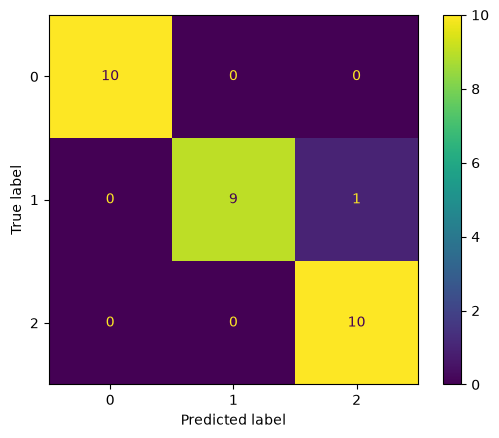

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.show()

# Reading the Confusion Matrix

The rows represent the actual classes.

The columns represent the predicted classes.

Values on the diagonal represent correct predictions.

Values outside the diagonal represent incorrect predictions.

In [20]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
)

precision = precision_score(
    y_test,
    predictions,
    average="weighted",
)

recall = recall_score(
    y_test,
    predictions,
    average="weighted",
)

f1 = f1_score(
    y_test,
    predictions,
    average="weighted",
)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Precision: 0.9697
Recall:    0.9667
F1-score:  0.9666


# Why `average="weighted"`?

Iris is a multi-class classification problem.

Precision, recall, and F1-score need an averaging strategy when there are multiple classes.

`weighted` calculates the metric for each class and averages them according to the number of true observations in each class.

For this balanced Iris dataset, the weighted metrics are easy to interpret.

We will later discuss other averaging strategies when they become relevant.

In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Accuracy vs Other Metrics

Accuracy tells us how many predictions were correct overall.

Precision, recall, and F1-score provide additional information about the model's classification performance.

For a balanced dataset such as Iris, accuracy can be useful.

For imbalanced classification problems, relying only on accuracy can be misleading.

# Interpreting the Classification Report

The model achieved 0.9667 accuracy on the test set.

Class 0 was classified perfectly.

Class 1 had a recall of 0.90, meaning the model correctly identified 90% of the actual class-1 observations.

Class 2 had a precision of 0.91, meaning most observations predicted as class 2 were actually class 2.

The macro and weighted averages are both approximately 0.97.

Because all three classes have equal support in this test set, the macro and weighted averages are the same.

# Key Takeaways

- Accuracy measures overall correctness.
- A confusion matrix shows where classification errors occur.
- Precision focuses on false positives.
- Recall focuses on false negatives.
- F1-score balances precision and recall.
- Classification reports provide these metrics for each class.
- Macro averaging gives every class equal importance.
- Weighted averaging accounts for the number of observations in each class.

# Interview Insight

### Precision vs Recall

Precision asks:

"Of everything the model predicted as positive, how much was actually positive?"

Recall asks:

"Of everything that was actually positive, how much did the model find?"

### When is recall especially important?

When missing a positive case is costly.

### When is precision especially important?

When false alarms or false positives are costly.

### What is F1-score?

The harmonic mean of precision and recall.

# Notebook Summary

In this notebook, we learned:

- Why accuracy alone can be insufficient.
- How to read a confusion matrix.
- Precision.
- Recall.
- F1-score.
- Classification reports.
- Macro and weighted averaging.
- How different metrics describe different types of model errors.

# What's Next?

Next, we'll learn **Regression Evaluation Metrics**.

We already used MAE, MSE, RMSE, and R² in the earlier regression work.

Now we'll make sure we properly understand what those metrics mean and when to use them.